In [1]:
from colorama import Fore
from IPython.display import display, Math

from astropy.io import fits
from scipy.io import readsav
from scipy.stats import gaussian_kde
from scipy import stats as ss
import numpy as np
import pandas as pd
import os
import copy

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

import tools as t

In [2]:
# load TS1
path_data = '../data/sim_series/'  # directory where the files are saved
data_spectra = fits.getdata(path_data + f'flux_norm_6173_lionel_tau1_spatialscaling1_sansrotation_serie0.fits')
data_spectra = np.array(data_spectra)

times = np.arange(0, len(data_spectra) * 144, 144) / 60 / 24  # time in days, same for all time series

In [3]:
# Parameters

N = 3686  # timesteps
M = 20  # PCs
TS = 1

# Load data

X = []
y = []

for i in range(N):

    data = torch.load(f'../data/PCA/TS{TS}/t_{i}.pt')

    X.append(data['scores'].float())
    y.append(torch.as_tensor(data['rv'], dtype=torch.float32))

X = torch.stack(X)
y = torch.stack(y).reshape(-1, 1)

print("Total X shape:", X.shape)
print("Total y shape:", y.shape)

/tmp/ipykernel_1886428/2577428456.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(f'../data/PCA/TS{TS}/t_{i}.pt')


Total X shape: torch.Size([3686, 20])
Total y shape: torch.Size([3686, 1])


In [4]:
# RV stats
print(f'Mean: {y.mean().item()}')
print(f'Sigma: {y.std().item()}')
print(f'Min: {y.min().item()}')
print(f'Max: {y.max().item()}')

Mean: -3.8809319646837537e-10
Sigma: 0.9465776681900024
Min: -3.7014224529266357
Max: 3.3682401180267334


In [5]:
batch_size = 32

# Chronological train/test split

train_size = int(0.7 * N)

X_train = X[:train_size]
y_train = y[:train_size]

X_test = X[train_size:]
y_test = y[train_size:]

print("Train X shape:", X_train.shape)
print("Train y shape:", y_train.shape)

print("Test X shape:", X_test.shape)
print("Test y shape:", y_test.shape)

# Scaling scores
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train.numpy())
X_test_scaled = scaler.transform(X_test.numpy())

X_train = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test = torch.tensor(X_test_scaled, dtype=torch.float32)

# Create Datasets
# Pair the rows of X with the corresponding rows of y

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

# Create DataLoaders
# takes a Dataset and gives samples to the model in batches

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True  # The model sees the same 80% of the data, but in a different order each epoch
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False  # There's no benefit to shuffling it because we're not updating the model during testing
)

Train X shape: torch.Size([2580, 20])
Train y shape: torch.Size([2580, 1])
Test X shape: torch.Size([1106, 20])
Test y shape: torch.Size([1106, 1])


In [6]:
# Model
# M = 10 PCs
model = nn.Sequential(
    nn.Linear(M, 32),
    nn.ReLU(),

    nn.Linear(32, 16),
    nn.ReLU(),

    nn.Linear(16, 1),
)


# Loss and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=0
)


# Training
epochs = 400
model_history = {
    'y_train_true': [],
    'y_train_pred': [],
    'diff_train': [],
    'loss_train': [],
    #'y_test_true': [],
    #'y_test_pred': [],
    #'diff_test': [],
    #'loss_test': [],
}
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:

        # Forward pass
        y_pred = model(X_batch)

        # Calculate loss
        loss = criterion(y_pred, y_batch)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # Average loss over batches
    train_loss /= len(train_loader)

    # Evaluate all sets
    y_tr_true, y_tr_pred, diff_tr, loss_tr = t.evaluate_model(train_loader, model, criterion)
    #y_te_true, y_te_pred, diff_te, loss_te = t.evaluate_model(test_loader, model, criterion)

    # Save evaluation
    model_history['y_train_true'].append(y_tr_true)
    model_history['y_train_pred'].append(y_tr_pred)
    model_history['diff_train'].append(diff_tr)
    model_history['loss_train'].append(loss_tr)

    #model_history['y_test_true'].append(y_te_true)
    #model_history['y_test_pred'].append(y_te_pred)
    #model_history['diff_test'].append(diff_te)
    #model_history['loss_test'].append(loss_te)


    # Print progress
    if epoch % (epochs // 10) == 0 or epoch == epochs - 1:
        print(
            f"Epoch {epoch}: "
            f"train loss = {train_loss:.4f}"
        )

Epoch 0: train loss = 0.8901
Epoch 40: train loss = 0.0367
Epoch 80: train loss = 0.0295
Epoch 120: train loss = 0.0265
Epoch 160: train loss = 0.0249
Epoch 200: train loss = 0.0237
Epoch 240: train loss = 0.0229
Epoch 280: train loss = 0.0221
Epoch 320: train loss = 0.0215
Epoch 360: train loss = 0.0210
Epoch 399: train loss = 0.0205


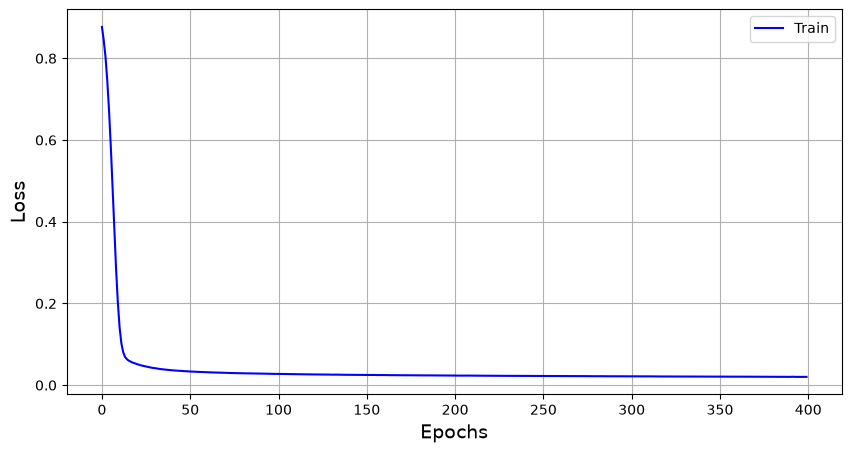

In [7]:
# plot loss history

fig, ax = plt.subplots(figsize=(10, 5))
ax.grid()

ax.plot(model_history['loss_train'], color='blue', label='Train')
#ax.plot(model_history['loss_test'], color='red', label='Test')

ax.set_xlabel('Epochs', size=14)
ax.set_ylabel('Loss', size=14)
#ax.set_yscale('log')
ax.legend()

plt.show()

In [8]:
# Evaluating the best model
model.eval()

# Evaluate training set
y_train_true, y_train_pred, diff_train, loss_train = t.evaluate_model(train_loader, model, criterion)

# Evaluate testing set
y_test_true, y_test_pred, diff_test, loss_test = t.evaluate_model(test_loader, model, criterion)

# Print results
print('---------- Best model average loss ----------')
print(f'Train loss: {loss_train:.4f}')
print(f'Test loss: {loss_test:.4f}')

---------- Best model average loss ----------
Train loss: 0.0203
Test loss: 0.0361


In [9]:
# best model loss for each point

criterion_L1    = nn.L1Loss(reduction="none")
criterion_MSE   = nn.MSELoss(reduction="none")
criterion_Huber = nn.HuberLoss(reduction="none")

loss_L1_train = criterion_L1(torch.tensor(y_train_pred), torch.tensor(y_train_true))
loss_MSE_train = criterion_MSE(torch.tensor(y_train_pred), torch.tensor(y_train_true))
loss_Huber_train = criterion_Huber(torch.tensor(y_train_pred), torch.tensor(y_train_true))

loss_L1_test = criterion_L1(torch.tensor(y_test_pred), torch.tensor(y_test_true))
loss_MSE_test = criterion_MSE(torch.tensor(y_test_pred), torch.tensor(y_test_true))
loss_Huber_test = criterion_Huber(torch.tensor(y_test_pred), torch.tensor(y_test_true))

Standard deviation of the predicted train RVs: 0.928
Standard deviation of the train RVs: 0.941

Standard deviation of the predicted test RVs: 0.896
Standard deviation of the test RVs: 0.920



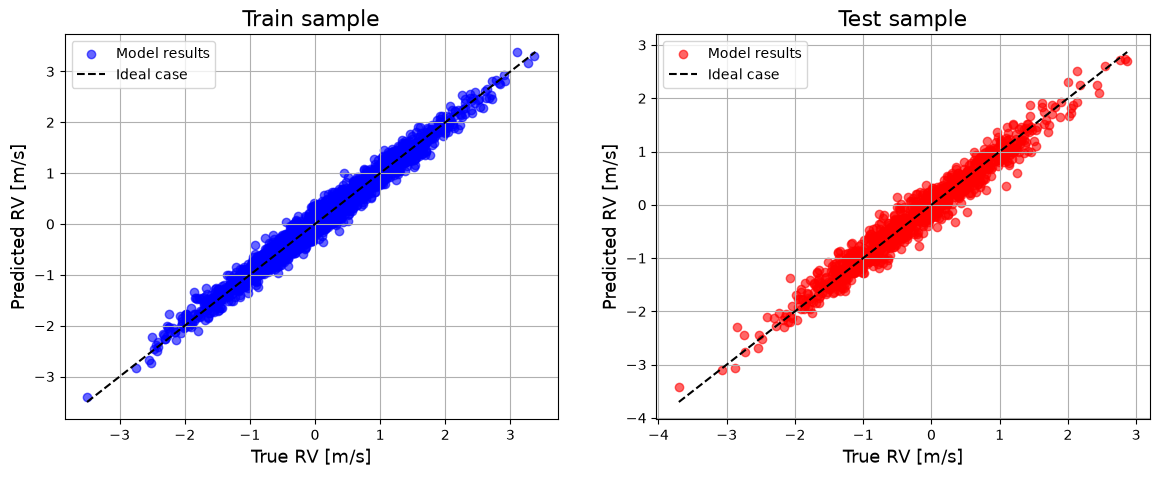

In [10]:
# plot true vs predicted for each sample
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

t.plot_true_vs_pred(y_train_true, y_train_pred, axs[0], 'blue')
t.plot_true_vs_pred(y_test_true, y_test_pred, axs[1], 'red')

axs[0].set_title('Train sample', size=16)
axs[1].set_title('Test sample', size=16)

print(Fore.BLUE + f'Standard deviation of the predicted train RVs: {y_train_pred.std():.3f}')
print(Fore.BLUE + f'Standard deviation of the train RVs: {y_train.std():.3f}\n')

print(Fore.RED + f'Standard deviation of the predicted test RVs: {y_test_pred.std():.3f}')
print(Fore.RED + f'Standard deviation of the test RVs: {y_test.std():.3f}\n')

In [11]:
# arange data to superpose the plots above
data_train = {
    'y_train_true': y_train_true,
    'y_train_pred': y_train_pred,
}


data_test = {
    'y_test_true': y_test_true,
    'y_test_pred': y_test_pred
}

df_train = pd.DataFrame(data=data_train)
df_test = pd.DataFrame(data=data_test)

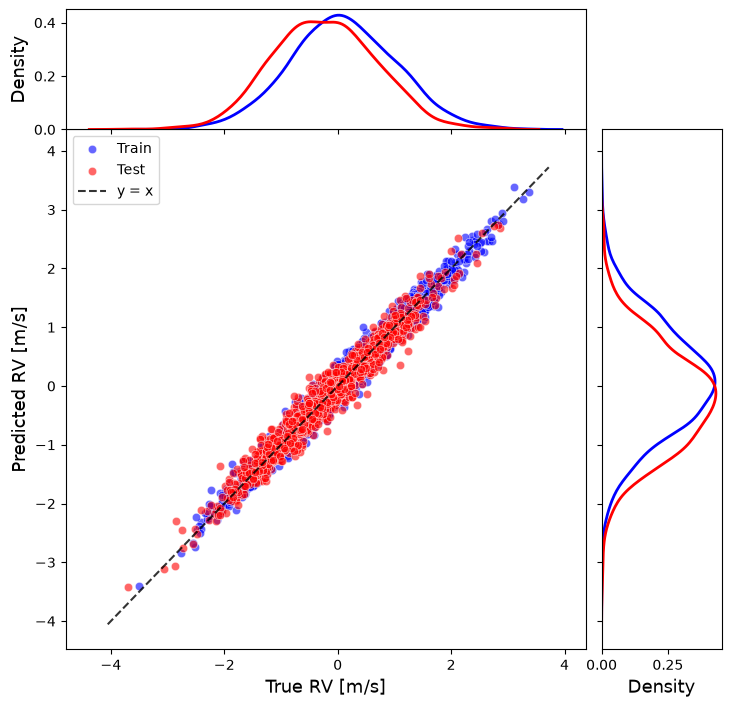

In [12]:
# Superposed with histograms

fig = plt.figure(figsize=(8, 8))

# Main scatter plot
ax = fig.add_axes([0.12, 0.12, 0.65, 0.65])

sns.scatterplot(
    data=df_train,
    x='y_train_true',
    y='y_train_pred',
    color='blue',
    alpha=.6,
    label='Train',
    ax=ax
)

sns.scatterplot(
    data=df_test,
    x='y_test_true',
    y='y_test_pred',
    color='red',
    alpha=.6,
    label='Test',
    ax=ax
)

# Reference line y = x
lims = ax.get_xlim()
ax.plot(lims, lims, '--', color='black', alpha=0.8, label='y = x')

ax.set_xlabel('True RV [m/s]', size=13)
ax.set_ylabel('Predicted RV [m/s]', size=13)
ax.legend()


# ---- Smooth marginal distributions ----

# Top: distributions of TRUE values
ax_top = fig.add_axes([0.12, 0.77, 0.65, 0.15], sharex=ax)

sns.kdeplot(
    data=df_train,
    x='y_train_true',
    color='blue',
    linewidth=2,
    ax=ax_top,
    label='Train'
)

sns.kdeplot(
    data=df_test,
    x='y_test_true',
    color='red',
    linewidth=2,
    ax=ax_top,
    label='Test'
)

ax_top.set_ylabel('Density', size=13)
ax_top.set_xlabel('')
ax_top.tick_params(axis='x', labelbottom=False)


# Right: distributions of PREDICTED values
ax_right = fig.add_axes([0.79, 0.12, 0.15, 0.65], sharey=ax)

sns.kdeplot(
    data=df_train,
    y='y_train_pred',
    color='blue',
    linewidth=2,
    ax=ax_right,
    label='Train'
)

sns.kdeplot(
    data=df_test,
    y='y_test_pred',
    color='red',
    linewidth=2,
    ax=ax_right,
    label='Test'
)

ax_right.set_xlabel('Density', size=13)
ax_right.set_ylabel('')
ax_right.tick_params(axis='y', labelleft=False)

plt.show()

In [13]:
# true - predicted for each sample
diff_train = y_train_true - y_train_pred
diff_test = y_test_true - y_test_pred

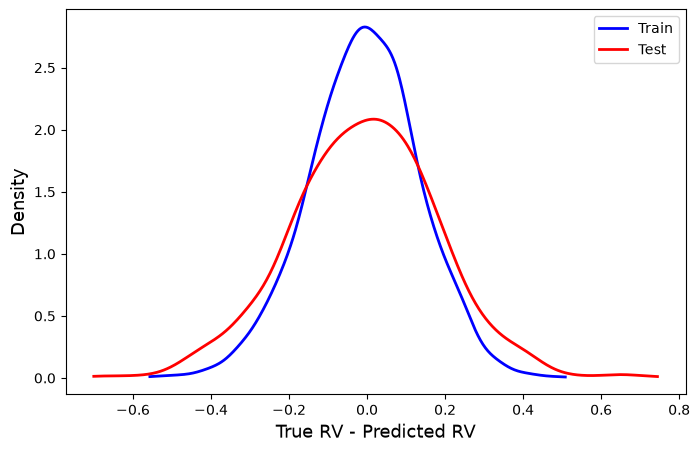

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))

#ax.hist(diff_train, alpha=.5, density=True)
#ax.hist(diff_val, alpha=.5, density=True)
#ax.hist(diff_test, alpha=.5, density=True)

# Smooth KDE curve
# gaussian_kde: estimates the probability density function of a random variable
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.gaussian_kde.html
kde_train = gaussian_kde(diff_train)
x_train = np.linspace(diff_train.min(), diff_train.max(), 500)

kde_test = gaussian_kde(diff_test)
x_test = np.linspace(diff_test.min(), diff_test.max(), 500)

# Density histograms
ax.plot(x_train, kde_train(x_train), linewidth=2, color='blue', label='Train')
ax.plot(x_test, kde_test(x_test), linewidth=2, color='red', label='Test')

ax.set_xlabel('True RV - Predicted RV', size=13)
ax.set_ylabel('Density', size=13)
ax.legend()

plt.show()

In [15]:
# compute means
mean_train = np.mean(diff_train)
mean_test = np.mean(diff_test)

# compute stds
std_train = np.std(diff_train)
std_test = np.std(diff_test)

In [16]:
print('---------- Mean of True-Predicted RV ----------')
print(f'Train: {mean_train:.5f}')
print(f'Test: {mean_test:.5f}')

print('---------- Std of True-Predicted RV ----------')
print(f'Train: {std_train:.4f}')
print(f'Test: {std_test:.4f}')

---------- Mean of True-Predicted RV ----------
Train: -0.00766
Test: -0.00698
---------- Std of True-Predicted RV ----------
Train: 0.1423
Test: 0.1902


In [17]:
# calculate std of True-Predicted (sigma) for each epoch

sigma_train = np.array(model_history['y_train_true']) - np.array(model_history['y_train_pred'])
#sigma_test = np.array(model_history['y_test_true']) - np.array(model_history['y_test_pred'])

sigma_train = np.std(sigma_train, axis=1)
#sigma_test = np.std(sigma_test, axis=1)

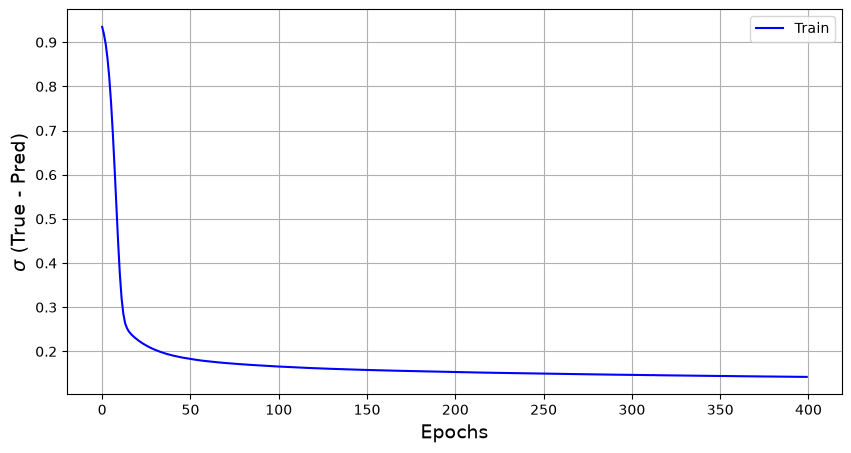

In [18]:
# plot sigma history

fig, ax = plt.subplots(figsize=(10, 5))
ax.grid()

ax.plot(sigma_train, color='blue', label='Train')
#ax.plot(sigma_test, color='red', label='Test')

ax.set_xlabel('Epochs', size=14)
ax.set_ylabel(r'$\sigma$ (True - Pred)', size=14)
ax.legend()
#ax.set_yscale('log')

plt.show()

In [42]:
# do a linear model (y = I * X) to compare with the result from the neural network
k = 20  # number of PCs used for the fit

scores_matrix = np.array(X)[:, :k]  # this is I in the fit, a matrix whose columns are the scores of the first k principal components

# separate the scores and RVs into sub samples
scores_train = np.array(X)[:train_size, :k]
scores_test  = np.array(X)[train_size:, :k]

rv = np.squeeze(np.array(y))  # RV data in a 1-d array
rv_train = rv[:train_size]
rv_test  = rv[train_size:]

# training the linear model

G = np.dot(scores_train.T, scores_train)
b = np.dot(scores_train.T, rv_train)
alpha = np.linalg.solve(G, b)

/tmp/ipykernel_1886428/1088659544.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  scores_matrix = np.array(X)[:, :k]  # this is I in the fit, a matrix whose columns are the scores of the first k principal components
/tmp/ipykernel_1886428/1088659544.py:7: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  scores_train = np.array(X)[:train_size, :k]
/tmp/ipykernel_1886428/1088659544.py:8: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing c

In [76]:
# use alpha to predict the RVs in batches of 21 points from the test sample
y_test_linear = []
res_test_linear = []
i = 0
chunk_size = 21

while i < len(rv_test):
    if i + chunk_size < len(rv_test):  # check that we are not depassing the number of data points while indexing
        scores_i = scores_test[i:i+chunk_size]
        rv_true = rv_test[i:i+chunk_size]
    else:
        scores_i = scores_test[i:]
        rv_true = rv_test[i:]

    pred = np.dot(alpha, scores_i.T)
    y_test_linear.append(pred)
    res_test_linear.append(rv_true - pred)
    i += chunk_size

print(f'{len(y_test_linear) - 1} chunks of {chunk_size} points and 1 chunk of {len(y_test_linear[-1])} points.')

52 chunks of 21 points and 1 chunk of 14 points.


In [77]:
mean_res_test_linear = np.array([np.mean(i) for i in res_test_linear])
std_res_test_linear = np.array([np.std(i) for i in res_test_linear])

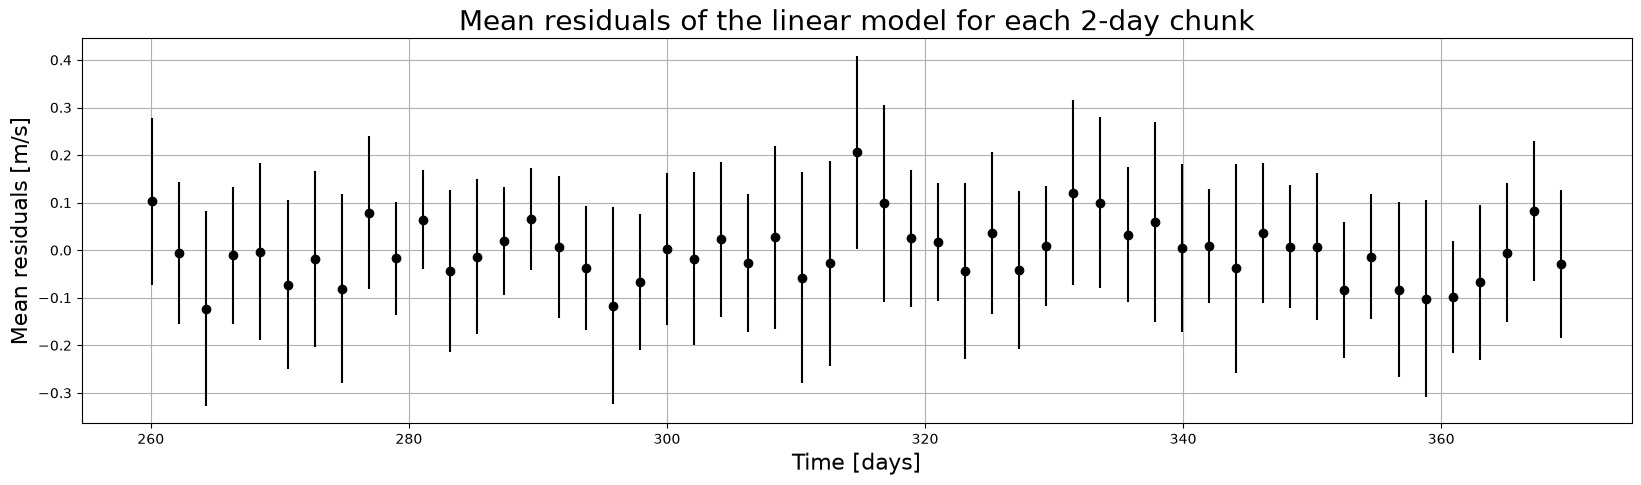

In [84]:
batch_array = (np.linspace(1, len(y_test_linear), len(y_test_linear)) * 21 + train_size) * 144 / 60 / 24  # array of days corresponding to the test sample

fig, ax = plt.subplots(figsize=(20, 5))
ax.grid()
ax.set_title('Mean residuals of the linear model for each 2-day chunk', size=20)

ax.errorbar(batch_array, mean_res_test_linear, std_res_test_linear, color='k', fmt='o')
ax.set_xlabel('Time [days]', size=16)
ax.set_ylabel('Mean residuals [m/s]', size=16)

plt.show()

In [90]:
y_test_linear_flat = np.concatenate(y_test_linear).tolist()

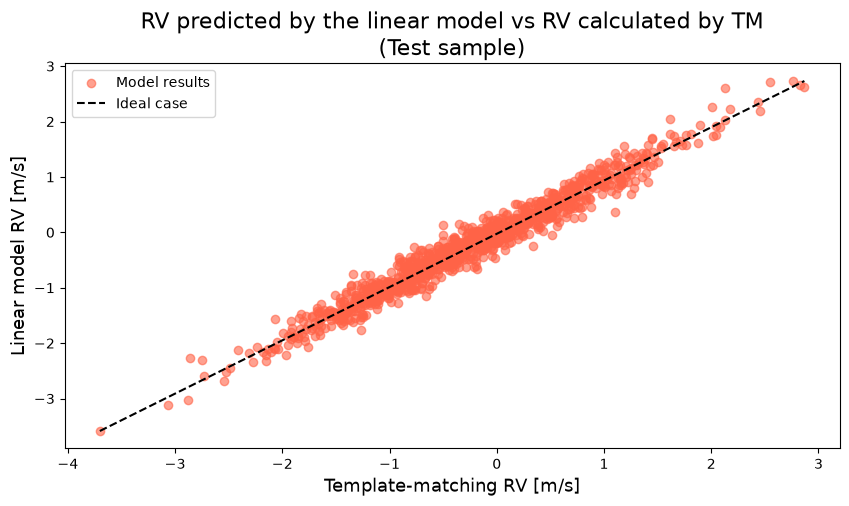

In [91]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_title('RV predicted by the linear model vs RV calculated by TM\n(Test sample)', size=16)

ax.scatter(rv_test, y_test_linear_flat, color='tomato', alpha=.6, label='Model results')
ax.plot([min(rv_test), max(rv_test)], [min(y_test_linear_flat), max(y_test_linear_flat)], linestyle='--', color='k', label='Ideal case')
ax.set_xlabel('Template-matching RV [m/s]', size=13)
ax.set_ylabel('Linear model RV [m/s]', size=13)
ax.legend()

plt.show()

In [46]:
times_test = times[train_size:]

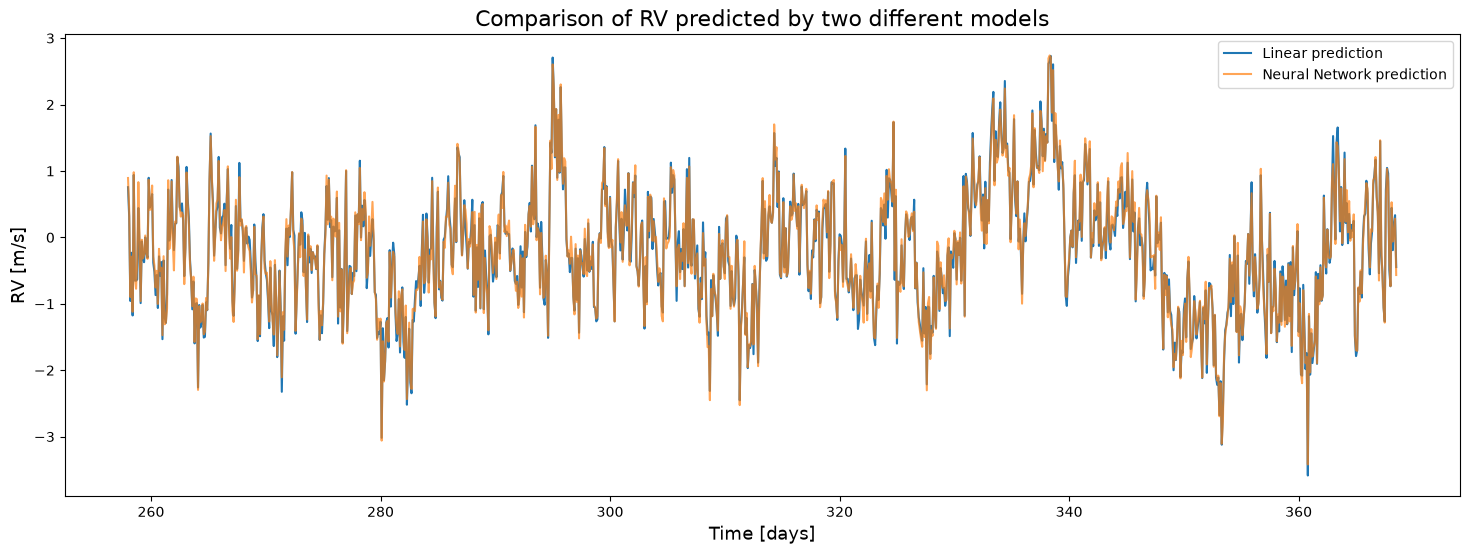

In [47]:
fig, ax = plt.subplots(figsize=(18, 6))
ax.set_title('Comparison of RV predicted by two different models', size=16)

ax.plot(times_test, y_test_linear, label='Linear prediction')
ax.plot(times_test, y_test_pred, label='Neural Network prediction', alpha=.7)
#plt.plot(times_test, rv[train_size + val_size:])

ax.set_xlabel('Time [days]', size=13)
ax.set_ylabel('RV [m/s]', size=13)
ax.legend()

plt.show()

In [48]:
print('---------- Mean difference between True and predicted RVs ----------')
print(f'True RV - Linear prediction = {np.mean(y_test_true - y_test_linear):.3f} m/s')
print(f'True RV - Neural Network prediction = {np.mean(y_test_true - np.array(y_test_pred)):.3f} m/s')
print(f'Linear prediction - Neural Network prediction = {np.mean(y_test_linear - np.array(y_test_pred)):.3f} m/s')

print('---------- Standard deviation of the difference between True and predicted RVs ----------')
print(f'True RV - Linear prediction = {np.std(diff_test_linear):.2f} m/s')
print(f'True RV - Neural Network prediction = {std_test:.2f} m/s')
print(f'Linear prediction - Neural Network prediction = {np.std(y_test_linear - np.array(y_test_pred)):.2f} m/s')

---------- Mean difference between True and predicted RVs ----------
True RV - Linear prediction = -0.002 m/s
True RV - Neural Network prediction = -0.007 m/s
Linear prediction - Neural Network prediction = -0.005 m/s
---------- Standard deviation of the difference between True and predicted RVs ----------
True RV - Linear prediction = 0.18 m/s
True RV - Neural Network prediction = 0.19 m/s
Linear prediction - Neural Network prediction = 0.10 m/s


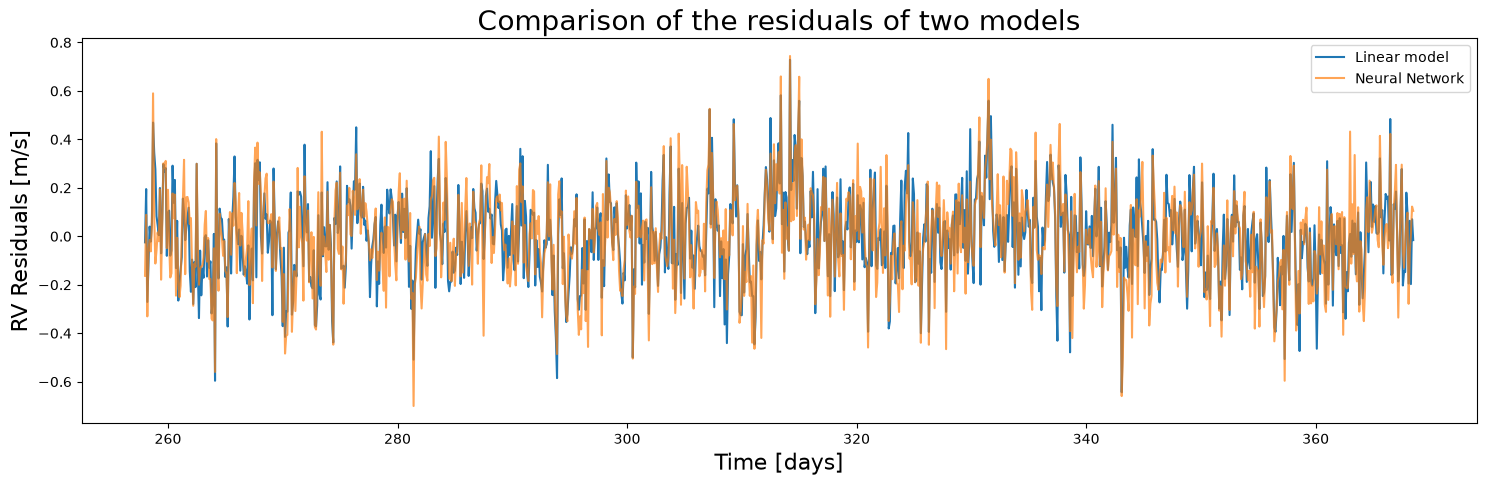

In [49]:
fig, ax = plt.subplots(figsize=(18, 5))
ax.set_title('Comparison of the residuals of two models', size=20)

ax.plot(times_test, y_test_true - y_test_linear, label='Linear model')
ax.plot(times_test, diff_test, label='Neural Network', alpha=.7)

ax.set_xlabel('Time [days]', size=16)
ax.set_ylabel('RV Residuals [m/s]', size=16)
ax.legend()

plt.show()

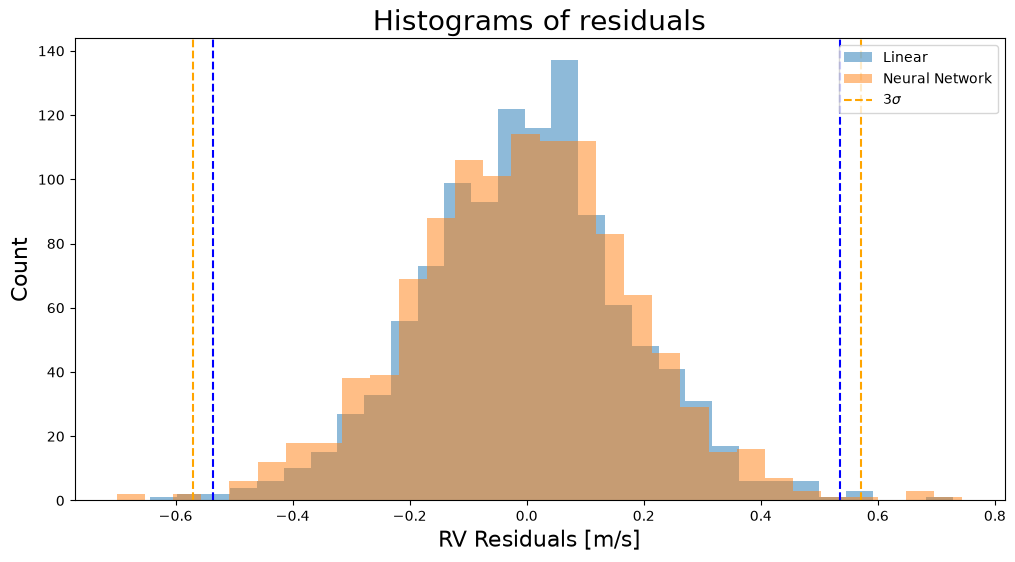

In [50]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_title('Histograms of residuals', size=20)

ax.hist(diff_test_linear, bins=30, alpha=0.5, label='Linear')
ax.hist(diff_test, bins=30, alpha=0.5, label='Neural Network')

# plot 1 sigma
#ax.axvline(np.std(diff_test_linear), color='blue')
#ax.axvline(-np.std(diff_test_linear), color='blue')
#ax.axvline(std_test, color='orange')
#ax.axvline(-std_test, color='orange')

# plot 3 sigma
ax.axvline(3 * np.std(diff_test_linear), color='blue', linestyle='--')
ax.axvline(-3 * np.std(diff_test_linear), color='blue', linestyle='--')
ax.axvline(3 * std_test, color='orange', linestyle='--')
ax.axvline(-3 * std_test, color='orange', linestyle='--', label=r'$3\sigma$')

ax.set_xlabel('RV Residuals [m/s]', size=16)
ax.set_ylabel('Count', size=16)
ax.legend()

plt.show()

In [51]:
# are PCs correlated with the residuals
diff_all = np.concatenate((diff_train, diff_test))
corr_all = []

for i in range(M):
    scores_i = scores_matrix[:, i]
    corr = ss.pearsonr(diff_all, scores_i)[0]
    corr_all.append(corr)

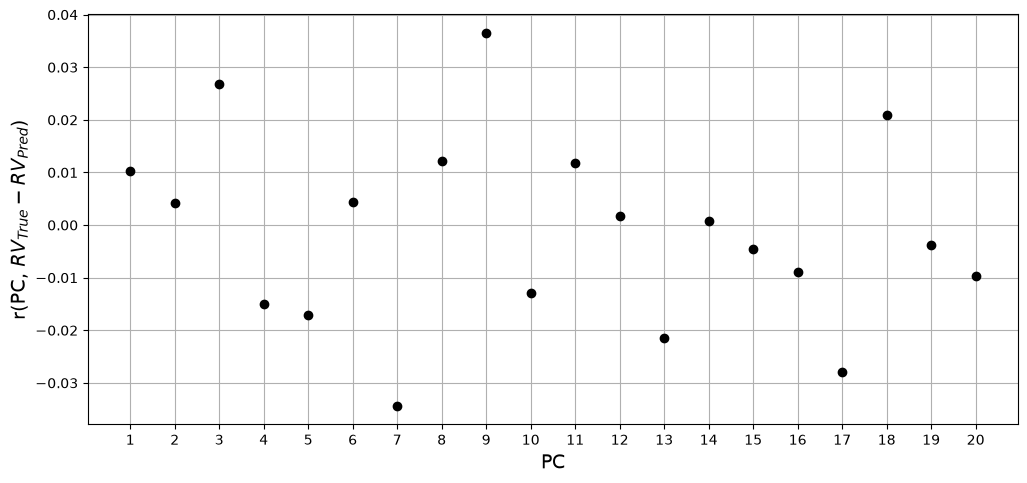

In [52]:
pc_arr = np.linspace(1, M, M)

fig, ax = plt.subplots(figsize=(12, 5))
ax.grid()

ax.scatter(pc_arr, corr_all, color='k', zorder=2)
ax.set_xlabel('PC', size=14)
ax.set_xticks(pc_arr)
ax.set_ylabel(r'r(PC, $RV_{True} - RV_{Pred}$)', size=14)

plt.subplots_adjust(top=.93)
plt.show()